# Эксперименты с embedding-моделями и классификаторами

Этот ноутбук проводит серию экспериментов для multi-label классификации отзывов: разные модели эмбеддингов + разные классические классификаторы сверху.

## Зачем нужен ноутбук

На вход подаются:

```text
train dataset:
data/labeled/wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2/
chatgpt_labeled_reviews_mvp_combined.csv
```

```text
golden set:
data/labeled/wb_feedbacks_manual_check_random_gpt5_prompt_test_v5/
manual_check_random_by_class_gpt5_relabelled.csv
```

Цель этапа — проверить, какая связка embedding-модели и классификатора лучше решает задачу multi-label классификации отзывов.

## Что делает ноутбук

1. Загружает train dataset и golden set.
2. Строит эмбеддинги текстов отзывов.
3. Обучает несколько классификаторов поверх эмбеддингов.
4. Оценивает качество на golden set.
5. Сохраняет метрики по каждому классу и общие summary-метрики.
6. Сохраняет обученные классификаторы и кэш эмбеддингов.

## Используемые embedding-модели

```text
deepvk/USER-bge-m3
BAAI/bge-m3
intfloat/multilingual-e5-base
intfloat/multilingual-e5-large-instruct
ai-forever/ru-en-RoSBERTa
```

Ссылки на модели:

- https://huggingface.co/deepvk/USER-bge-m3
- https://huggingface.co/BAAI/bge-m3
- https://huggingface.co/intfloat/multilingual-e5-base
- https://huggingface.co/intfloat/multilingual-e5-large-instruct
- https://huggingface.co/ai-forever/ru-en-RoSBERTa

## Используемые классификаторы

```text
LinearSVC
LinearSVC_balanced
LogisticRegression_balanced
Ridge_balanced
SGD_hinge_balanced
SGD_log_loss_balanced
RandomForest
```

## Выходные данные

```text
data/labeled/embedding_classifier_experiments/
```

Основные файлы:

```text
summary_metrics.csv
per_class_metrics.csv
```

Также сохраняются:

```text
embeddings_cache/
trained_classifiers/
plots/
```

## Роль в пайплайне

```text
GPT-5 train dataset + golden set
        ↓
embedding_classifier_experiments_reviews.ipynb
        ↓
сравнение embedding-моделей и классификаторов
        ↓
выбор лучших связок для дальнейшего threshold tuning
```

На этом этапе выбираются лучшие кандидаты для следующего эксперимента с подбором порогов по классам.

In [38]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# Если запускаешь в Colab / чистом окружении, раскомментируй установку.
# !pip -q install -U sentence-transformers scikit-learn pandas numpy matplotlib tqdm joblib

In [40]:
import ast
import gc
import json
import os
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Конфигурация

In [41]:
# === УКАЖИ СВОЙ ПУТЬ ===
# Если в твоем старом ноутбуке уже есть переменная labeled_dir, можно оставить как есть.
try:
    labeled_dir
except NameError:
    labeled_dir = "/content/drive/MyDrive/MLops_project/project/data/labeled"  # поменяй на свой путь

labeled_dir = Path(labeled_dir)

GOLDEN_PATH = labeled_dir / "wb_feedbacks_manual_check_random_gpt5_prompt_test_v5" / "manual_check_random_by_class_gpt5_relabelled.csv"
TRAIN_PATH = labeled_dir / "wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2" / "chatgpt_labeled_reviews_mvp_combined.csv"

OUTPUT_DIR = labeled_dir / "embedding_classifier_experiments"
EMB_DIR = OUTPUT_DIR / "embeddings_cache"
MODEL_DIR = OUTPUT_DIR / "trained_classifiers"
PLOTS_DIR = OUTPUT_DIR / "plots"

for p in [OUTPUT_DIR, EMB_DIR, MODEL_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("GOLDEN_PATH:", GOLDEN_PATH)
print("TRAIN_PATH:", TRAIN_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

GOLDEN_PATH: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_manual_check_random_gpt5_prompt_test_v5/manual_check_random_by_class_gpt5_relabelled.csv
TRAIN_PATH: /content/drive/MyDrive/MLops_project/project/data/labeled/wb_feedbacks_ChatGpt_markup_from_synthetic_gpt5_V_2/chatgpt_labeled_reviews_mvp_combined.csv
OUTPUT_DIR: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments


In [42]:
# 4 embedding-модели.
# Если память/время ограничены, можешь временно закомментировать тяжелые модели.
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

EMBEDDING_MODELS = {
    "USER-bge-m3": "deepvk/USER-bge-m3",
    "bge-m3": "BAAI/bge-m3",
    "ru-en-RoSBERTa": "ai-forever/ru-en-RoSBERTa",
    "multilingual-e5-base": "intfloat/multilingual-e5-base",
}


CLASSIFIERS = {
    "LogReg_balanced": lambda: OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE
        ),
        n_jobs=-1
    ),

    "LinearSVC_balanced": lambda: OneVsRestClassifier(
        LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        n_jobs=-1
    ),

    "Ridge_balanced": lambda: OneVsRestClassifier(
        RidgeClassifier(
            class_weight="balanced"
        ),
        n_jobs=-1
    ),

    "SGD_logloss_balanced": lambda: OneVsRestClassifier(
        SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            max_iter=3000,
            tol=1e-4,
            random_state=RANDOM_STATE
        ),
        n_jobs=-1
    ),

    "SGD_hinge_balanced": lambda: OneVsRestClassifier(
        SGDClassifier(
            loss="hinge",
            class_weight="balanced",
            max_iter=3000,
            tol=1e-4,
            random_state=RANDOM_STATE
        ),
        n_jobs=-1
    ),

    "ExtraTrees_balanced": lambda: OneVsRestClassifier(
        ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        n_jobs=-1
    ),

    "RandomForest_balanced": lambda: OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        n_jobs=-1
    ),
}

BATCH_SIZE = 64
NORMALIZE_EMBEDDINGS = True
DROP_EXACT_TRAIN_TEST_LEAKAGE = True

## 2. Утилиты для чтения и нормализации labels

In [43]:
def read_csv_smart(path: Path) -> pd.DataFrame:
    """Читает csv с несколькими частыми кодировками."""
    encodings = ["utf-8", "utf-8-sig", "cp1251"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def parse_labels_cell(x):
    """Парсит labels из list / json / python-list-string / строки через ; | , ."""
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    if isinstance(x, (list, tuple, set)):
        raw = list(x)
    else:
        s = str(x).strip()
        if not s or s.lower() in {"nan", "none", "null", "[]"}:
            return []

        parsed = None
        if s.startswith("[") or s.startswith("{"):
            for parser in (json.loads, ast.literal_eval):
                try:
                    parsed = parser(s)
                    break
                except Exception:
                    pass

        if isinstance(parsed, dict):
            # На случай формата {"labels": [...]}.
            if "labels" in parsed:
                raw = parsed["labels"]
            elif "new_labels" in parsed:
                raw = parsed["new_labels"]
            else:
                raw = list(parsed.values())
        elif isinstance(parsed, (list, tuple, set)):
            raw = list(parsed)
        elif parsed is not None:
            raw = [parsed]
        else:
            # fallback для строк вида: label1; label2 или label1 | label2
            if ";" in s:
                raw = s.split(";")
            elif "|" in s:
                raw = s.split("|")
            elif "," in s and not (s.startswith("[") and s.endswith("]")):
                raw = s.split(",")
            else:
                raw = [s]

    labels = []
    for item in raw:
        if item is None or (isinstance(item, float) and pd.isna(item)):
            continue
        label = str(item).strip().strip('"').strip("'").strip()
        if label and label.lower() not in {"nan", "none", "null"}:
            labels.append(label)

    # Убираем дубли, сохраняя порядок.
    return list(dict.fromkeys(labels))


def find_column(df, candidates, required=True):
    """Ищет колонку по списку возможных названий."""
    lower_map = {str(c).lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lower_map:
            return lower_map[key]
    if required:
        raise ValueError(f"Не нашел колонку. Кандидаты: {candidates}. Есть колонки: {list(df.columns)}")
    return None


def safe_name(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9а-яА-Я_-]+", "_", s).strip("_")

## 3. Загрузка train и golden set

In [44]:
train_df = read_csv_smart(TRAIN_PATH)
golden_df = read_csv_smart(GOLDEN_PATH)

print("Train shape:", train_df.shape)
print("Golden shape:", golden_df.shape)
print("Train columns:", list(train_df.columns))
print("Golden columns:", list(golden_df.columns))

Train shape: (1820, 9)
Golden shape: (150, 17)
Train columns: ['отзыв', 'old_labels', 'new_labels', 'labels', 'source_type', 'source_files', 'source_row_ids', 'old_labels_str', 'new_labels_str']
Golden columns: ['manual_check_id', 'class_for_check', 'source_type', 'отзыв', 'old_labels', 'new_labels', 'correct_labels', 'old_labels_str', 'new_labels_str', 'correct_labels_str', 'labels_changed', 'new_equals_correct', 'comment', 'source_class_file', 'labels', 'labels_str', 'is_correct']


In [45]:
# Golden set: строго по твоему описанию — колонки 'отзыв', 'new_labels'.
GOLDEN_TEXT_COL = "отзыв"
GOLDEN_LABEL_COL = "new_labels"

if GOLDEN_TEXT_COL not in golden_df.columns:
    raise ValueError(f"В golden set нет колонки {GOLDEN_TEXT_COL!r}. Есть: {list(golden_df.columns)}")
if GOLDEN_LABEL_COL not in golden_df.columns:
    raise ValueError(f"В golden set нет колонки {GOLDEN_LABEL_COL!r}. Есть: {list(golden_df.columns)}")

# Train: ожидаем 'отзыв' и 'labels', но делаем fallback на частые варианты.
TRAIN_TEXT_COL = find_column(train_df, ["отзыв", "review", "review_text", "text", "feedback", "comment"])
TRAIN_LABEL_COL = find_column(train_df, ["labels", "new_labels", "label", "target", "classes"])

print("TRAIN_TEXT_COL:", TRAIN_TEXT_COL)
print("TRAIN_LABEL_COL:", TRAIN_LABEL_COL)
print("GOLDEN_TEXT_COL:", GOLDEN_TEXT_COL)
print("GOLDEN_LABEL_COL:", GOLDEN_LABEL_COL)

TRAIN_TEXT_COL: отзыв
TRAIN_LABEL_COL: labels
GOLDEN_TEXT_COL: отзыв
GOLDEN_LABEL_COL: new_labels


In [46]:
train = train_df[[TRAIN_TEXT_COL, TRAIN_LABEL_COL]].copy()
train.columns = ["text", "labels"]
train["text"] = train["text"].map(normalize_text)
train["labels"] = train["labels"].map(parse_labels_cell)
train = train[(train["text"] != "") & (train["labels"].map(len) > 0)].copy()

golden = golden_df[[GOLDEN_TEXT_COL, GOLDEN_LABEL_COL]].copy()
golden.columns = ["text", "labels"]
golden["text"] = golden["text"].map(normalize_text)
golden["labels"] = golden["labels"].map(parse_labels_cell)
golden = golden[(golden["text"] != "") & (golden["labels"].map(len) > 0)].copy()

# Убираем точные дубли внутри train и golden.
train = train.drop_duplicates(subset=["text"]).reset_index(drop=True)
golden = golden.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Важно: если golden попал в train, это утечка. По умолчанию удаляем exact match из train.
if DROP_EXACT_TRAIN_TEST_LEAKAGE:
    golden_texts = set(golden["text"])
    before = len(train)
    train = train[~train["text"].isin(golden_texts)].reset_index(drop=True)
    print(f"Удалено exact-overlap из train по тексту: {before - len(train)}")

print("Train after cleaning:", train.shape)
print("Golden after cleaning:", golden.shape)

train.head()

Удалено exact-overlap из train по тексту: 87
Train after cleaning: (1733, 2)
Golden after cleaning: (147, 2)


,text,labels
0,Не держится. Какая то пленка …,[Проблема с качеством товара]
1,"Куртка хорошая, качественная! Замок правда зли...",[Проблема с качеством товара]
2,"Задумка не плохая, но качество материала не по...",[Проблема с качеством товара]
3,"Остаются темные потеки от конденсата,которые н...",[Проблема с качеством товара]
4,"К сожалению, пришли разбитые. Поэтому отказ",[Проблема с качеством товара]


In [47]:
all_labels = sorted(set(label for labels in pd.concat([train["labels"], golden["labels"]]) for label in labels))
print("Всего классов:", len(all_labels))
for i, label in enumerate(all_labels, 1):
    print(f"{i:02d}. {label}")

mlb = MultiLabelBinarizer(classes=all_labels)
Y_train = mlb.fit_transform(train["labels"])
Y_golden = mlb.transform(golden["labels"])

label_names = list(mlb.classes_)

train_counts = pd.Series(Y_train.sum(axis=0), index=label_names).sort_values(ascending=False)
golden_counts = pd.Series(Y_golden.sum(axis=0), index=label_names).sort_values(ascending=False)

counts_df = pd.DataFrame({
    "train_support": train_counts,
    "golden_support": golden_counts,
}).fillna(0).astype(int)

counts_df

Всего классов: 9
01. Другая проблема
02. Несоответствие карточке товара
03. Положительный / нейтральный отзыв
04. Проблема доставки / получения
05. Проблема с возвратом
06. Проблема с качеством товара
07. Проблема с комплектацией / упаковкой
08. Проблема с размером / посадкой
09. Цена / ценность


,train_support,golden_support
Другая проблема,66,5
Несоответствие карточке товара,231,32
Положительный / нейтральный отзыв,201,21
Проблема доставки / получения,205,18
Проблема с возвратом,230,21
Проблема с качеством товара,598,43
Проблема с комплектацией / упаковкой,421,24
Проблема с размером / посадкой,210,23
Цена / ценность,183,17


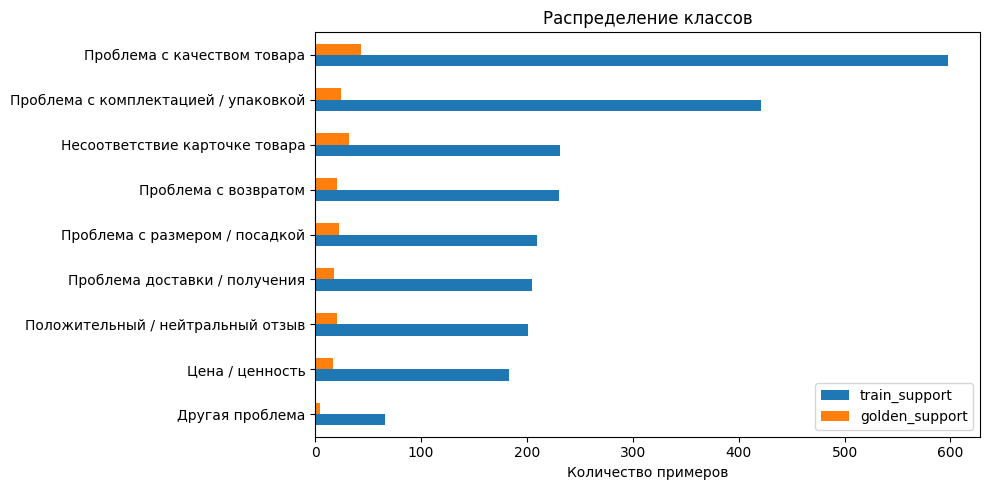

In [48]:
# Быстрый график распределения классов в train и golden.
ax = counts_df.sort_values("train_support", ascending=True).plot(
    kind="barh", figsize=(10, max(5, 0.35 * len(counts_df))), title="Распределение классов"
)
ax.set_xlabel("Количество примеров")
plt.tight_layout()
plt.show()

## 4. Расчет embeddings с кешированием

In [49]:
def get_embeddings(model_key: str, model_name: str, texts, batch_size=64, normalize=True):
    """Считает embeddings и кеширует их в .npy."""
    from sentence_transformers import SentenceTransformer
    import torch

    cache_path = EMB_DIR / f"{safe_name(model_key)}__n{len(texts)}__norm{int(normalize)}.npy"
    if cache_path.exists():
        print(f"Загружаю embeddings из кеша: {cache_path}")
        return np.load(cache_path)

    print(f"Считаю embeddings: {model_key} -> {model_name}")
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
    )
    embeddings = embeddings.astype("float32")
    np.save(cache_path, embeddings)
    print(f"Сохранил embeddings: {cache_path}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return embeddings

## 5. Обучение и оценка 8 экспериментов

In [50]:
def evaluate_predictions(y_true, y_pred, label_names, model_key, classifier_key):
    """Возвращает per-class метрики и aggregate-метрики."""
    p, r, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        zero_division=0,
    )

    per_class = pd.DataFrame({
        "embedding_model": model_key,
        "classifier": classifier_key,
        "class": label_names,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support,
    })

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    summary = {
        "embedding_model": model_key,
        "classifier": classifier_key,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }
    return per_class, summary


def run_single_experiment(model_key, model_name, classifier_key, classifier_factory):
    print("=" * 100)
    print(f"Embedding model: {model_key} | Classifier: {classifier_key}")

    all_texts = pd.concat([train["text"], golden["text"]], ignore_index=True)
    all_embeddings = get_embeddings(
        model_key=model_key,
        model_name=model_name,
        texts=all_texts,
        batch_size=BATCH_SIZE,
        normalize=NORMALIZE_EMBEDDINGS,
    )

    X_train = all_embeddings[:len(train)]
    X_golden = all_embeddings[len(train):]

    clf = classifier_factory()
    clf.fit(X_train, Y_train)
    y_pred = clf.predict(X_golden)

    per_class, summary = evaluate_predictions(
        Y_golden,
        y_pred,
        label_names=label_names,
        model_key=model_key,
        classifier_key=classifier_key,
    )

    model_path = MODEL_DIR / f"{safe_name(model_key)}__{safe_name(classifier_key)}.joblib"
    joblib.dump(clf, model_path)
    print("Saved classifier:", model_path)
    print("Macro F1:", round(summary["macro_f1"], 4))

    return per_class, summary

In [51]:
all_per_class = []
all_summary = []

for model_key, model_name in EMBEDDING_MODELS.items():
    for classifier_key, classifier_factory in CLASSIFIERS.items():
        per_class_df, summary_dict = run_single_experiment(
            model_key=model_key,
            model_name=model_name,
            classifier_key=classifier_key,
            classifier_factory=classifier_factory,
        )
        all_per_class.append(per_class_df)
        all_summary.append(summary_dict)

per_class_metrics = pd.concat(all_per_class, ignore_index=True)
summary_metrics = pd.DataFrame(all_summary)

per_class_path = OUTPUT_DIR / "per_class_metrics.csv"
summary_path = OUTPUT_DIR / "summary_metrics.csv"

per_class_metrics.to_csv(per_class_path, index=False, encoding="utf-8-sig")
summary_metrics.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved:", per_class_path)
print("Saved:", summary_path)

Embedding model: USER-bge-m3 | Classifier: LogReg_balanced
Загружаю embeddings из кеша: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/embeddings_cache/USER-bge-m3__n1880__norm1.npy
Saved classifier: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/trained_classifiers/USER-bge-m3__LogReg_balanced.joblib
Macro F1: 0.7587
Embedding model: USER-bge-m3 | Classifier: LinearSVC_balanced
Загружаю embeddings из кеша: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/embeddings_cache/USER-bge-m3__n1880__norm1.npy
Saved classifier: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/trained_classifiers/USER-bge-m3__LinearSVC_balanced.joblib
Macro F1: 0.8052
Embedding model: USER-bge-m3 | Classifier: Ridge_balanced
Загружаю embeddings из кеша: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/

## 6. Итоговая таблица метрик

In [52]:
summary_metrics_sorted = summary_metrics.sort_values("macro_f1", ascending=False).reset_index(drop=True)
summary_metrics_sorted

,embedding_model,classifier,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1,weighted_precision,weighted_recall,weighted_f1
0,bge-m3,LinearSVC_balanced,0.768141,0.877154,0.813398,0.779221,0.882353,0.827586,0.789601,0.882353,0.830185
1,bge-m3,SGD_hinge_balanced,0.760692,0.878662,0.806388,0.781659,0.877451,0.826790,0.797510,0.877451,0.831447
2,USER-bge-m3,LinearSVC_balanced,0.757460,0.862693,0.805170,0.776824,0.887255,0.828375,0.779908,0.887255,0.828315
3,USER-bge-m3,Ridge_balanced,0.734463,0.909183,0.802490,0.750000,0.897059,0.816964,0.764375,0.897059,0.821002
4,bge-m3,Ridge_balanced,0.730781,0.888320,0.795356,0.755187,0.892157,0.817978,0.766601,0.892157,0.820833
5,ru-en-RoSBERTa,LinearSVC_balanced,0.741292,0.863198,0.793437,0.747863,0.857843,0.799087,0.755081,0.857843,0.800844
6,ru-en-RoSBERTa,SGD_logloss_balanced,0.732318,0.877733,0.786763,0.714859,0.872549,0.785872,0.737806,0.872549,0.790189
7,USER-bge-m3,SGD_logloss_balanced,0.748405,0.858137,0.782584,0.772727,0.833333,0.801887,0.797050,0.833333,0.805670
8,bge-m3,SGD_logloss_balanced,0.772671,0.835514,0.781864,0.788462,0.803922,0.796117,0.817916,0.803922,0.802016
9,ru-en-RoSBERTa,Ridge_balanced,0.714735,0.874688,0.780726,0.721311,0.862745,0.785714,0.732050,0.862745,0.788760


In [53]:
# Таблица per-class метрик для всех экспериментов.
per_class_metrics.sort_values(["class", "f1"], ascending=[True, False]).reset_index(drop=True)

,embedding_model,classifier,class,precision,recall,f1,support
0,ru-en-RoSBERTa,LinearSVC_balanced,Другая проблема,0.625000,1.000000,0.769231,5
1,ru-en-RoSBERTa,SGD_logloss_balanced,Другая проблема,0.625000,1.000000,0.769231,5
2,ru-en-RoSBERTa,Ridge_balanced,Другая проблема,0.555556,1.000000,0.714286,5
3,ru-en-RoSBERTa,LogReg_balanced,Другая проблема,0.500000,1.000000,0.666667,5
4,ru-en-RoSBERTa,SGD_hinge_balanced,Другая проблема,0.500000,1.000000,0.666667,5
...,...,...,...,...,...,...,...
247,multilingual-e5-base,ExtraTrees_balanced,Цена / ценность,1.000000,0.352941,0.521739,17
248,bge-m3,ExtraTrees_balanced,Цена / ценность,0.857143,0.352941,0.500000,17
249,multilingual-e5-base,RandomForest_balanced,Цена / ценность,1.000000,0.294118,0.454545,17
250,ru-en-RoSBERTa,ExtraTrees_balanced,Цена / ценность,1.000000,0.235294,0.380952,17


In [54]:
# Удобная сводная таблица F1 по классам: строки — классы, колонки — эксперименты.
per_class_metrics["experiment"] = per_class_metrics["embedding_model"] + " + " + per_class_metrics["classifier"]
f1_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="f1")
recall_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="recall")
precision_pivot = per_class_metrics.pivot_table(index="class", columns="experiment", values="precision")

f1_pivot

experiment,USER-bge-m3 + ExtraTrees_balanced,USER-bge-m3 + LinearSVC_balanced,USER-bge-m3 + LogReg_balanced,USER-bge-m3 + RandomForest_balanced,USER-bge-m3 + Ridge_balanced,USER-bge-m3 + SGD_hinge_balanced,USER-bge-m3 + SGD_logloss_balanced,bge-m3 + ExtraTrees_balanced,bge-m3 + LinearSVC_balanced,bge-m3 + LogReg_balanced,...,multilingual-e5-base + Ridge_balanced,multilingual-e5-base + SGD_hinge_balanced,multilingual-e5-base + SGD_logloss_balanced,ru-en-RoSBERTa + ExtraTrees_balanced,ru-en-RoSBERTa + LinearSVC_balanced,ru-en-RoSBERTa + LogReg_balanced,ru-en-RoSBERTa + RandomForest_balanced,ru-en-RoSBERTa + Ridge_balanced,ru-en-RoSBERTa + SGD_hinge_balanced,ru-en-RoSBERTa + SGD_logloss_balanced
class,,,,,,,,,,,,,,,,,,,,,
Другая проблема,0.000000,0.545455,0.470588,0.000000,0.588235,0.600000,0.555556,0.000000,0.571429,0.526316,...,0.555556,0.107527,0.400000,0.000000,0.769231,0.666667,0.000000,0.714286,0.666667,0.769231
Несоответствие карточке товара,0.060606,0.825397,0.769231,0.171429,0.838710,0.781250,0.785714,0.117647,0.793651,0.781250,...,0.705882,0.597938,0.679245,0.000000,0.787879,0.774194,0.000000,0.776119,0.771429,0.760563
Положительный / нейтральный отзыв,0.871795,0.837209,0.837209,0.900000,0.818182,0.857143,0.800000,0.842105,0.878049,0.837209,...,0.857143,0.782609,0.765957,0.687500,0.900000,0.878049,0.727273,0.900000,0.900000,0.900000
Проблема доставки / получения,0.666667,0.810811,0.744186,0.714286,0.789474,0.810811,0.789474,0.666667,0.833333,0.744186,...,0.697674,0.714286,0.833333,0.666667,0.750000,0.697674,0.714286,0.714286,0.714286,0.789474
Проблема с возвратом,0.320000,0.893617,0.840000,0.320000,0.893617,0.763636,0.857143,0.384615,0.893617,0.823529,...,0.800000,0.823529,0.750000,0.250000,0.844444,0.784314,0.500000,0.833333,0.826087,0.823529
Проблема с качеством товара,0.550725,0.824742,0.791667,0.571429,0.804124,0.818182,0.819277,0.531250,0.804124,0.791667,...,0.715789,0.701031,0.683544,0.562500,0.821053,0.791667,0.539683,0.787234,0.795699,0.804348
Проблема с комплектацией / упаковкой,0.484848,0.769231,0.701754,0.375000,0.750000,0.800000,0.754717,0.529412,0.754717,0.701754,...,0.714286,0.714286,0.693878,0.470588,0.703704,0.666667,0.484848,0.678571,0.745763,0.647059
Проблема с размером / посадкой,0.685714,0.897959,0.884615,0.722222,0.897959,0.779661,0.916667,0.685714,0.958333,0.901961,...,0.884615,0.846154,0.956522,0.685714,0.897959,0.920000,0.756757,0.920000,0.916667,0.920000
Цена / ценность,0.583333,0.842105,0.789474,0.640000,0.842105,0.780488,0.764706,0.500000,0.833333,0.842105,...,0.727273,0.769231,0.758621,0.380952,0.666667,0.631579,0.380952,0.702703,0.684211,0.666667


## 7. Графики

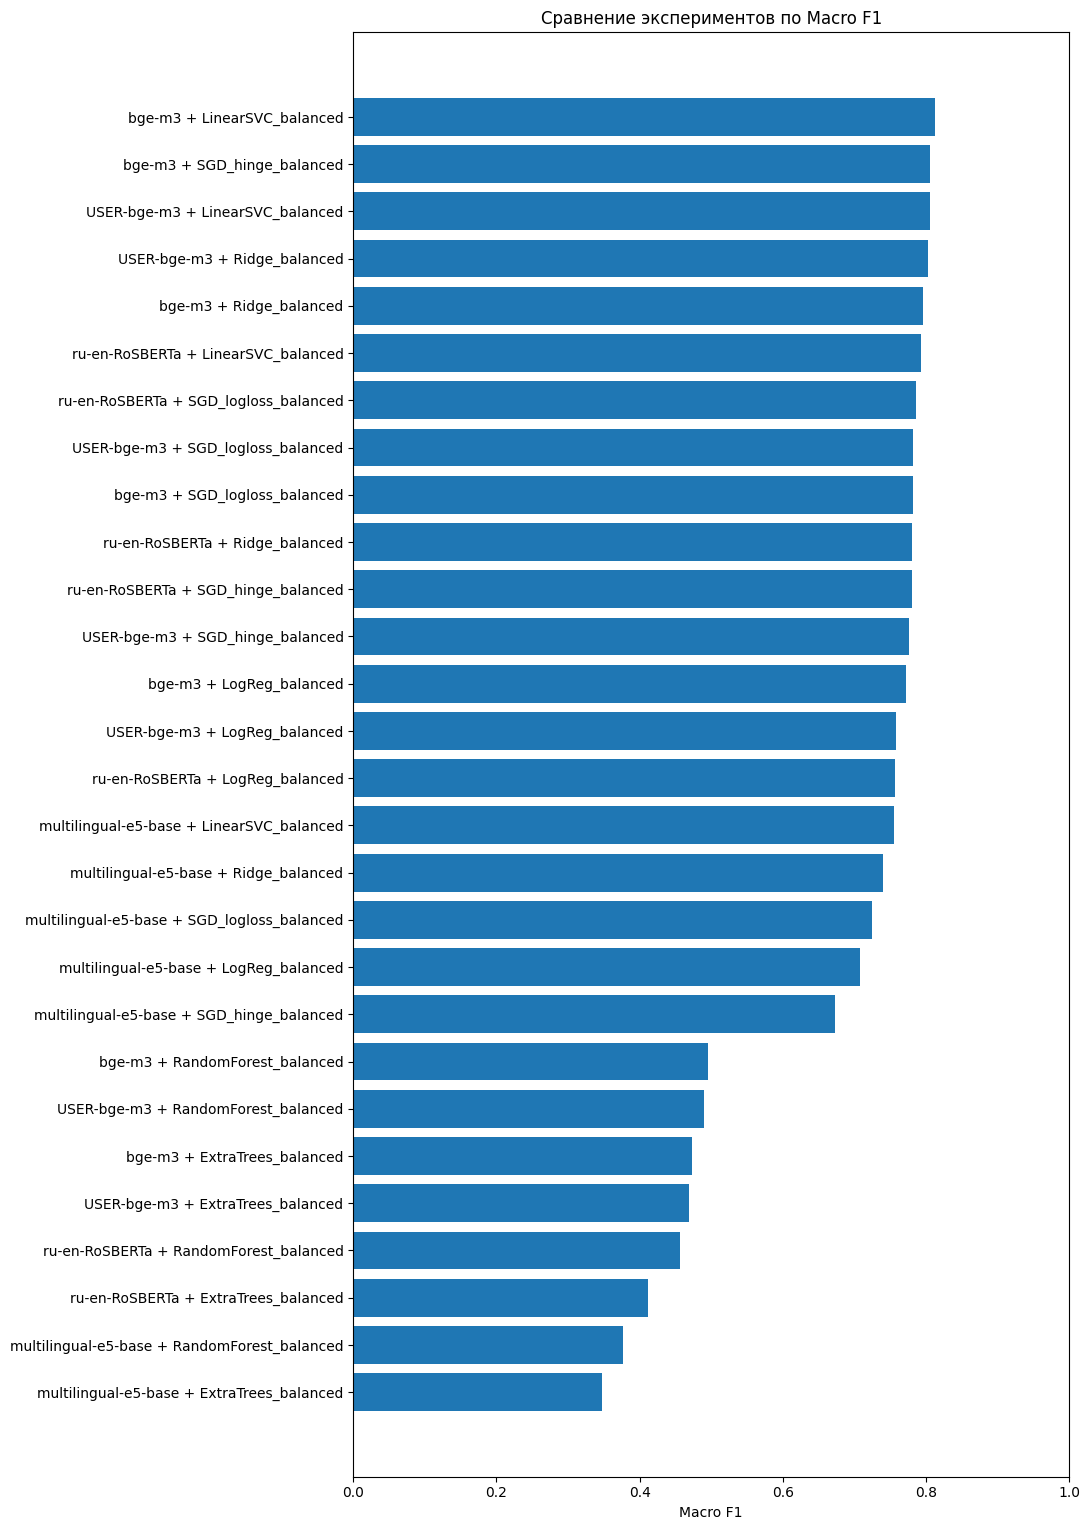

In [55]:
# График 1: macro F1 по экспериментам.
plot_df = summary_metrics_sorted.copy()
plot_df["experiment"] = plot_df["embedding_model"] + " + " + plot_df["classifier"]
plot_df = plot_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(11, max(5, 0.55 * len(plot_df))))
plt.barh(plot_df["experiment"], plot_df["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Сравнение экспериментов по Macro F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "macro_f1_by_experiment.png", dpi=200, bbox_inches="tight")
plt.show()

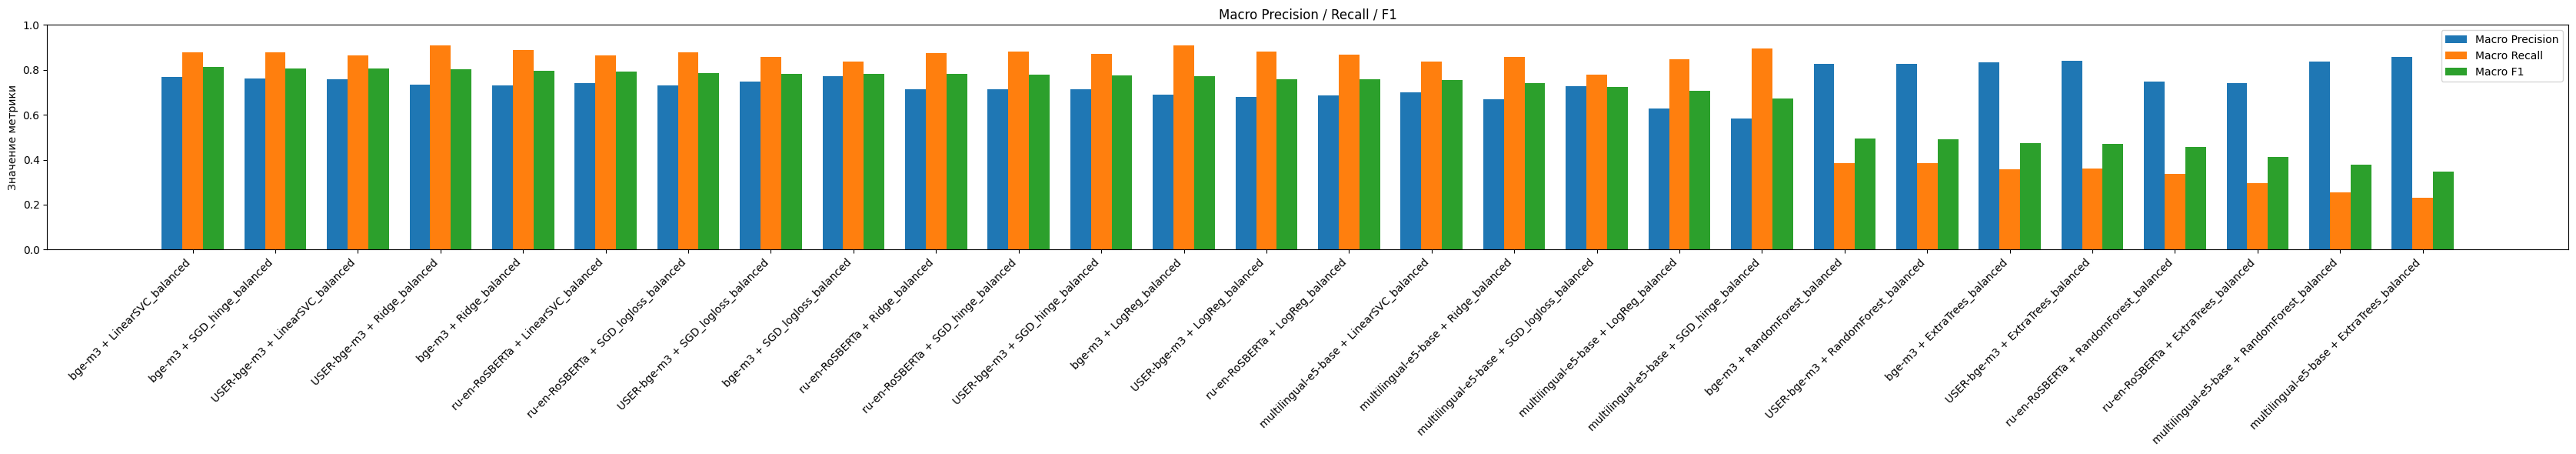

In [56]:
# График 2: macro precision / recall / F1 по экспериментам.
plot_df = summary_metrics_sorted.copy()
plot_df["experiment"] = plot_df["embedding_model"] + " + " + plot_df["classifier"]
plot_df = plot_df.sort_values("macro_f1", ascending=False)

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(max(12, 1.2 * len(plot_df)), 6))
plt.bar(x - width, plot_df["macro_precision"], width, label="Macro Precision")
plt.bar(x, plot_df["macro_recall"], width, label="Macro Recall")
plt.bar(x + width, plot_df["macro_f1"], width, label="Macro F1")
plt.xticks(x, plot_df["experiment"], rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title("Macro Precision / Recall / F1")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "macro_precision_recall_f1.png", dpi=200, bbox_inches="tight")
plt.show()

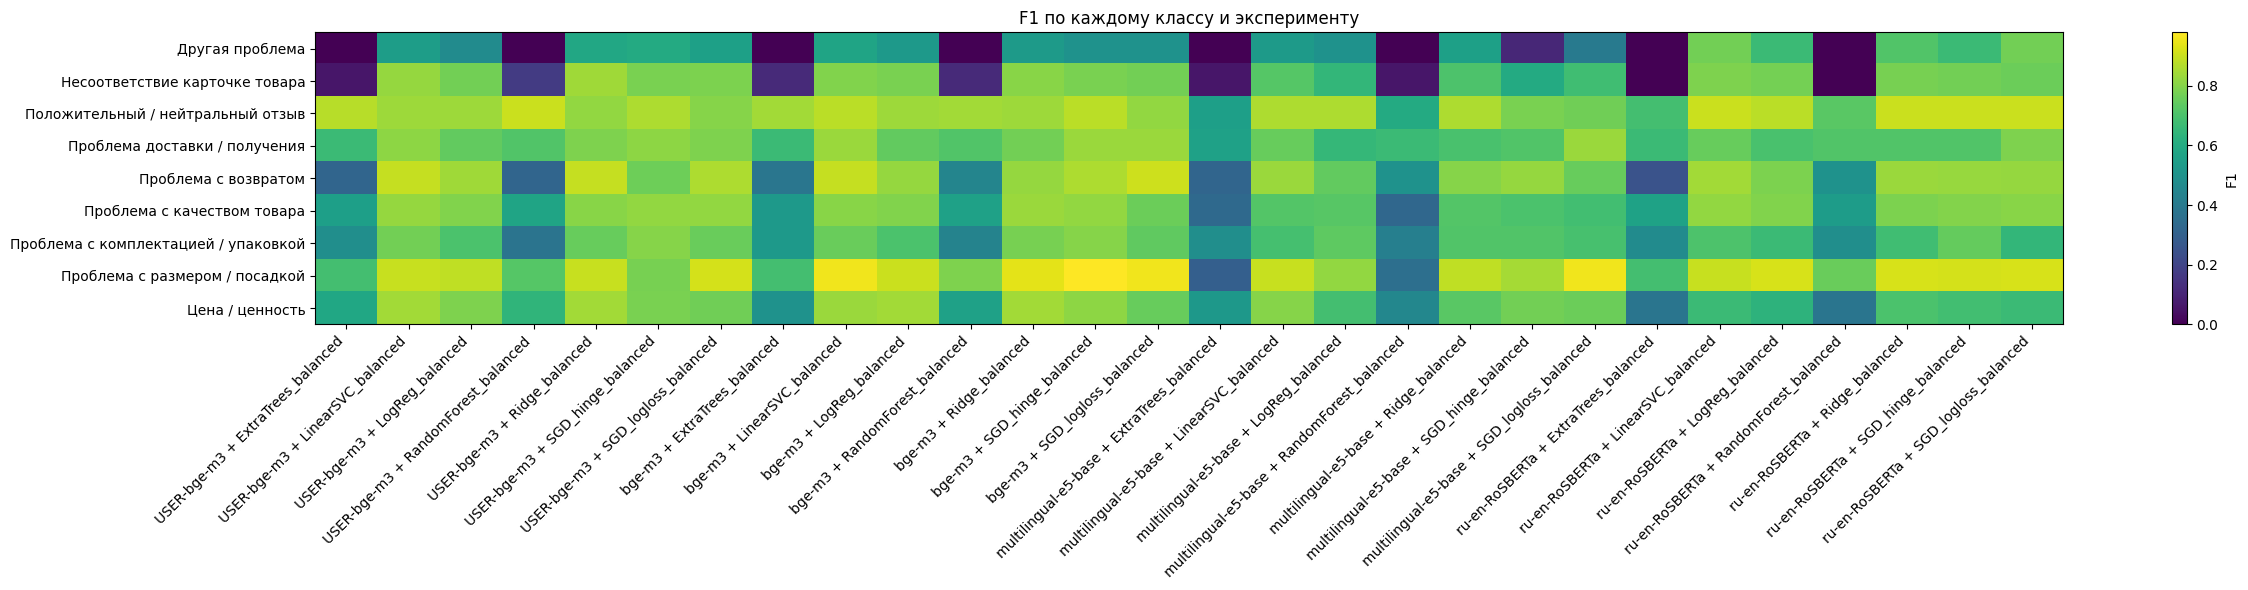

In [57]:
# График 3: heatmap F1 по классам и экспериментам.
# Чем светлее/темнее цвет — тем выше/ниже F1. Конкретная цветовая схема не задается.
heatmap_df = f1_pivot.copy().fillna(0)

plt.figure(figsize=(max(12, 0.9 * heatmap_df.shape[1]), max(6, 0.45 * heatmap_df.shape[0])))
plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label="F1")
plt.xticks(np.arange(heatmap_df.shape[1]), heatmap_df.columns, rotation=45, ha="right")
plt.yticks(np.arange(heatmap_df.shape[0]), heatmap_df.index)
plt.title("F1 по каждому классу и эксперименту")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_class_f1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

Лучший эксперимент: bge-m3 + LinearSVC_balanced


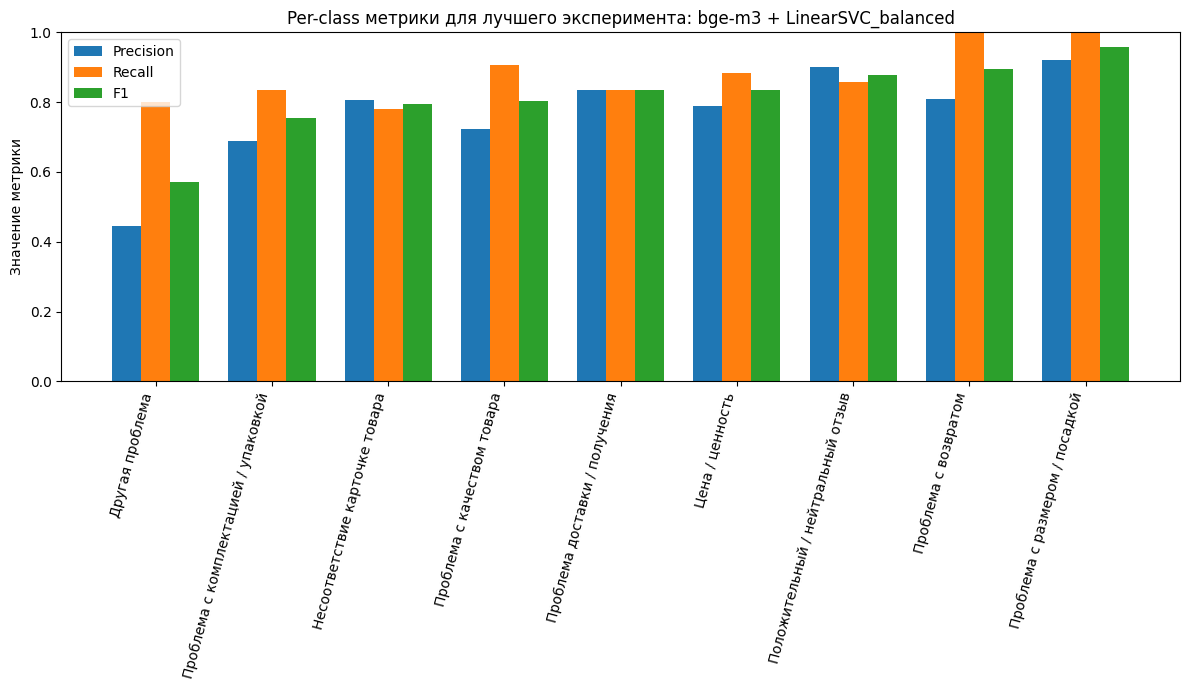

,embedding_model,classifier,class,precision,recall,f1,support,experiment
72,bge-m3,LinearSVC_balanced,Другая проблема,0.444444,0.800000,0.571429,5,bge-m3 + LinearSVC_balanced
78,bge-m3,LinearSVC_balanced,Проблема с комплектацией / упаковкой,0.689655,0.833333,0.754717,24,bge-m3 + LinearSVC_balanced
73,bge-m3,LinearSVC_balanced,Несоответствие карточке товара,0.806452,0.781250,0.793651,32,bge-m3 + LinearSVC_balanced
77,bge-m3,LinearSVC_balanced,Проблема с качеством товара,0.722222,0.906977,0.804124,43,bge-m3 + LinearSVC_balanced
75,bge-m3,LinearSVC_balanced,Проблема доставки / получения,0.833333,0.833333,0.833333,18,bge-m3 + LinearSVC_balanced
80,bge-m3,LinearSVC_balanced,Цена / ценность,0.789474,0.882353,0.833333,17,bge-m3 + LinearSVC_balanced
74,bge-m3,LinearSVC_balanced,Положительный / нейтральный отзыв,0.900000,0.857143,0.878049,21,bge-m3 + LinearSVC_balanced
76,bge-m3,LinearSVC_balanced,Проблема с возвратом,0.807692,1.000000,0.893617,21,bge-m3 + LinearSVC_balanced
79,bge-m3,LinearSVC_balanced,Проблема с размером / посадкой,0.920000,1.000000,0.958333,23,bge-m3 + LinearSVC_balanced


In [58]:
# График 4: precision/recall/F1 по классам для лучшего эксперимента.
best = summary_metrics_sorted.iloc[0]
best_model = best["embedding_model"]
best_classifier = best["classifier"]
print("Лучший эксперимент:", best_model, "+", best_classifier)

best_per_class = per_class_metrics[
    (per_class_metrics["embedding_model"] == best_model) &
    (per_class_metrics["classifier"] == best_classifier)
].copy().sort_values("f1", ascending=True)

x = np.arange(len(best_per_class))
width = 0.25

plt.figure(figsize=(max(12, 0.65 * len(best_per_class)), 7))
plt.bar(x - width, best_per_class["precision"], width, label="Precision")
plt.bar(x, best_per_class["recall"], width, label="Recall")
plt.bar(x + width, best_per_class["f1"], width, label="F1")
plt.xticks(x, best_per_class["class"], rotation=75, ha="right")
plt.ylim(0, 1)
plt.ylabel("Значение метрики")
plt.title(f"Per-class метрики для лучшего эксперимента: {best_model} + {best_classifier}")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_experiment_per_class_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

best_per_class

## 8. Где сохранены результаты

In [59]:
print("Метрики по экспериментам:", OUTPUT_DIR / "summary_metrics.csv")
print("Метрики по классам:", OUTPUT_DIR / "per_class_metrics.csv")
print("Кеш embeddings:", EMB_DIR)
print("Обученные классификаторы:", MODEL_DIR)
print("Графики:", PLOTS_DIR)

Метрики по экспериментам: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/summary_metrics.csv
Метрики по классам: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/per_class_metrics.csv
Кеш embeddings: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/embeddings_cache
Обученные классификаторы: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/trained_classifiers
Графики: /content/drive/MyDrive/MLops_project/project/data/labeled/embedding_classifier_experiments/plots


## 9. Как читать результат

Главная таблица — `summary_metrics_sorted`.

Сначала смотри:

- `macro_f1` — насколько модель в среднем хорошо работает по всем классам;
- `macro_recall` — насколько хорошо она находит проблемы каждого класса;
- `macro_precision` — насколько редко она ошибочно ставит лишние классы.

Потом обязательно смотри `best_per_class`: там видно, какие классы модель проваливает. Обычно самые проблемные пары:

- брак / низкое качество материала;
- упаковка / доставка;
- несоответствие описанию / несоответствие ожиданиям;
- цена / просто упоминание цены;
- положительный или нейтральный отзыв / скрытая жалоба.

Если какой-то класс имеет низкий recall, значит модель часто его пропускает. Если низкий precision, значит модель слишком часто ставит этот класс ошибочно.